In [9]:
import os
import glob
import subprocess
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Presentation-readable figure defaults
rcParams['legend.fontsize'] = 20
rcParams['axes.labelsize'] = 20
rcParams['axes.titlesize'] = 25
rcParams['xtick.labelsize'] = 20
rcParams['ytick.labelsize'] = 20

# ---- CONFIG ----
ROOT_DIR   = r"H:\jasmine\lick_videos"   # folder containing the .mp4 files
CHUNK_SIZE = 10000
CODEC      = "mp4v"        # reliable on conda/Windows; see note in run_all
EXPECTED_FPS = 30          # nominal; real timing comes from the CSV

In [10]:
def discover_videos(root_dir, exts=(".mp4",)):
    paths = []
    for ext in exts:
        paths.extend(glob.glob(os.path.join(root_dir, f"*{ext}")))
    paths = sorted(paths)
    videos = [{"path": p,
               "base": os.path.splitext(os.path.basename(p))[0]}
              for p in paths]
    print(f"Found {len(videos)} video(s):")
    for v in videos:
        print("  ", v["base"])
    return videos

videos = discover_videos(ROOT_DIR)

Found 24 video(s):
   260617_JSY083_PRE1
   260617_JSY084_PRE1
   260618_JSY083_B1
   260618_JSY084_B1
   260619_JSY083_B2
   260619_JSY084_B2
   260620_JSY083_B3
   260620_JSY084_B3
   260621_JSY083_B4
   260621_JSY084_B4
   260622_JSY083_B5
   260622_JSY084_B5
   260623_JSY083_B6
   260623_JSY084_B6
   260624_JSY083_B7
   260624_JSY084_B7
   260625_JSY083_B8
   260625_JSY084_B8
   260626_JSY083_Saline
   260626_JSY084_Saline
   260628_JSY083_DCZ100
   260628_JSY084_DCZ100
   260630_JSY083_DCZ200
   260630_JSY084_DCZ200


In [11]:
def get_video_info(path):
    cap = cv2.VideoCapture(path)
    if not cap.isOpened():
        raise IOError(f"Could not open {path}")
    info = {
        "fps":          cap.get(cv2.CAP_PROP_FPS),
        "total_frames": int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),  # may be wrong
        "width":        int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        "height":       int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
    }
    cap.release()
    return info

for v in videos:
    print(v["base"], get_video_info(v["path"]))

260617_JSY083_PRE1 {'fps': 30.000029865957316, 'total_frames': 54933, 'width': 1280, 'height': 720}
260617_JSY084_PRE1 {'fps': 28.98225771411393, 'total_frames': 54361, 'width': 1280, 'height': 720}
260618_JSY083_B1 {'fps': 30.000029982759912, 'total_frames': 54719, 'width': 1280, 'height': 720}
260618_JSY084_B1 {'fps': 30.00002968492841, 'total_frames': 55268, 'width': 1280, 'height': 720}
260619_JSY083_B2 {'fps': 30.000029756323663, 'total_frames': 64981, 'width': 1280, 'height': 720}
260619_JSY084_B2 {'fps': 30.000029798053177, 'total_frames': 64890, 'width': 1280, 'height': 720}
260620_JSY083_B3 {'fps': 30.000030252138743, 'total_frames': 63916, 'width': 1280, 'height': 720}
260620_JSY084_B3 {'fps': 30.000030360440064, 'total_frames': 63688, 'width': 1280, 'height': 720}
260621_JSY083_B4 {'fps': 29.994719495752538, 'total_frames': 73422, 'width': 1280, 'height': 720}
260621_JSY084_B4 {'fps': 30.00003015468293, 'total_frames': 71895, 'width': 1280, 'height': 720}
260622_JSY083_B5 {'

In [12]:
def extract_timestamps(path, save_csv=True):
    cmd = [
        "ffprobe", "-v", "error",
        "-select_streams", "v:0",
        "-show_entries", "frame=pts_time",
        "-of", "csv=print_section=0",
        path,
    ]
    out = subprocess.run(cmd, capture_output=True, text=True, check=True)
    pts = [float(line) for line in out.stdout.splitlines() if line.strip()]
    df = pd.DataFrame({
        "frame_idx": np.arange(len(pts)),
        "pts_time_s": pts,
    })
    df["interval_ms"] = df["pts_time_s"].diff() * 1000.0

    if save_csv:
        base = os.path.splitext(path)[0]
        csv_path = base + "_timestamps.csv"
        df.to_csv(csv_path, index=False)
        print(f"  saved {len(df)} timestamps -> {os.path.basename(csv_path)}")
    return df

In [13]:
def plot_intervals(df, title="inter-frame intervals"):
    iv = df["interval_ms"].dropna().values
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(iv, bins=100)
    ax.axvline(1000/EXPECTED_FPS, color="red", linestyle="--",
               label=f"target {1000/EXPECTED_FPS:.1f} ms")
    ax.set_xlabel("interval (ms)")
    ax.set_ylabel("count")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(f"  median={np.median(iv):.2f} ms  "
          f"p99={np.percentile(iv,99):.2f} ms  max={iv.max():.2f} ms")

In [14]:
def plan_chunks(total_frames, chunk_size=CHUNK_SIZE):
    spans = []
    start = 0
    while start < total_frames:
        end = min(start + chunk_size, total_frames)
        spans.append((start, end))
        start = end
    return spans

# sanity check on your example
demo = plan_chunks(56789)
print(demo, "| n_files =", len(demo), "| last len =", demo[-1][1]-demo[-1][0])

[(0, 10000), (10000, 20000), (20000, 30000), (30000, 40000), (40000, 50000), (50000, 56789)] | n_files = 6 | last len = 6789


In [15]:
def split_one(path, base, root_dir, chunk_size=CHUNK_SIZE, codec=CODEC):
    out_dir = os.path.join(root_dir, f"{base}_splited")
    os.makedirs(out_dir, exist_ok=True)

    cap = cv2.VideoCapture(path)
    if not cap.isOpened():
        raise IOError(f"Could not open {path}")

    fps    = cap.get(cv2.CAP_PROP_FPS) or EXPECTED_FPS
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fourcc = cv2.VideoWriter_fourcc(*codec)

    writer = None
    split_num = 0
    frames_in_chunk = 0
    total_read = 0
    pos_msec = []   # backend timestamp per frame, for cross-check

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # start a new file at each chunk boundary
        if frames_in_chunk == 0:
            split_num += 1
            out_path = os.path.join(out_dir, f"{base}_split{split_num}.mp4")
            writer = cv2.VideoWriter(out_path, fourcc, fps, (width, height))
            if not writer.isOpened():
                raise IOError(f"VideoWriter failed for codec '{codec}'. "
                              f"Try codec='mp4v'.")

        pos_msec.append(cap.get(cv2.CAP_PROP_POS_MSEC))
        writer.write(frame)
        frames_in_chunk += 1
        total_read += 1

        if frames_in_chunk == chunk_size:
            writer.release()
            writer = None
            frames_in_chunk = 0

    if writer is not None:
        writer.release()
    cap.release()

    # save the backend cross-check timestamps
    pd.DataFrame({"frame_idx": np.arange(total_read),
                  "pos_msec": pos_msec}).to_csv(
        os.path.join(out_dir, f"{base}_posmsec.csv"), index=False)

    print(f"  {base}: {total_read} frames -> {split_num} file(s) in {out_dir}")
    return {"total_read": total_read, "n_splits": split_num,
            "out_dir": out_dir}

Found 24 video(s):
   260617_JSY083_PRE1
   260617_JSY084_PRE1
   260618_JSY083_B1
   260618_JSY084_B1
   260619_JSY083_B2
   260619_JSY084_B2
   260620_JSY083_B3
   260620_JSY084_B3
   260621_JSY083_B4
   260621_JSY084_B4
   260622_JSY083_B5
   260622_JSY084_B5
   260623_JSY083_B6
   260623_JSY084_B6
   260624_JSY083_B7
   260624_JSY084_B7
   260625_JSY083_B8
   260625_JSY084_B8
   260626_JSY083_Saline
   260626_JSY084_Saline
   260628_JSY083_DCZ100
   260628_JSY084_DCZ100
   260630_JSY083_DCZ200
   260630_JSY084_DCZ200

=== 260617_JSY083_PRE1 ===
  saved 54933 timestamps -> 260617_JSY083_PRE1_timestamps.csv


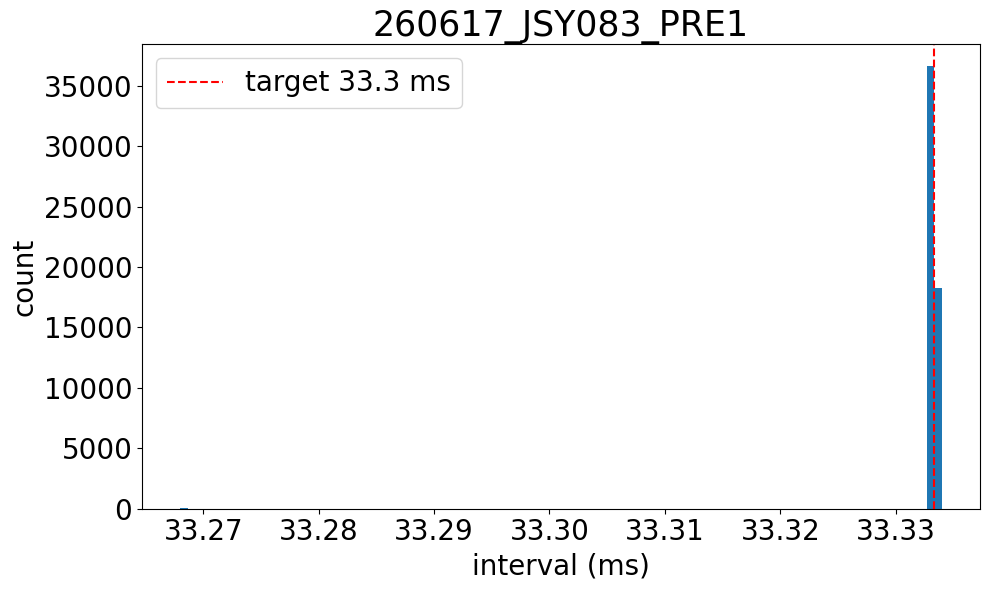

  median=33.33 ms  p99=33.33 ms  max=33.33 ms
  260617_JSY083_PRE1: 54933 frames -> 6 file(s) in H:\jasmine\lick_videos\260617_JSY083_PRE1_splited
  ffprobe frames=54933  written=54933  OK

=== 260617_JSY084_PRE1 ===
  saved 54361 timestamps -> 260617_JSY084_PRE1_timestamps.csv


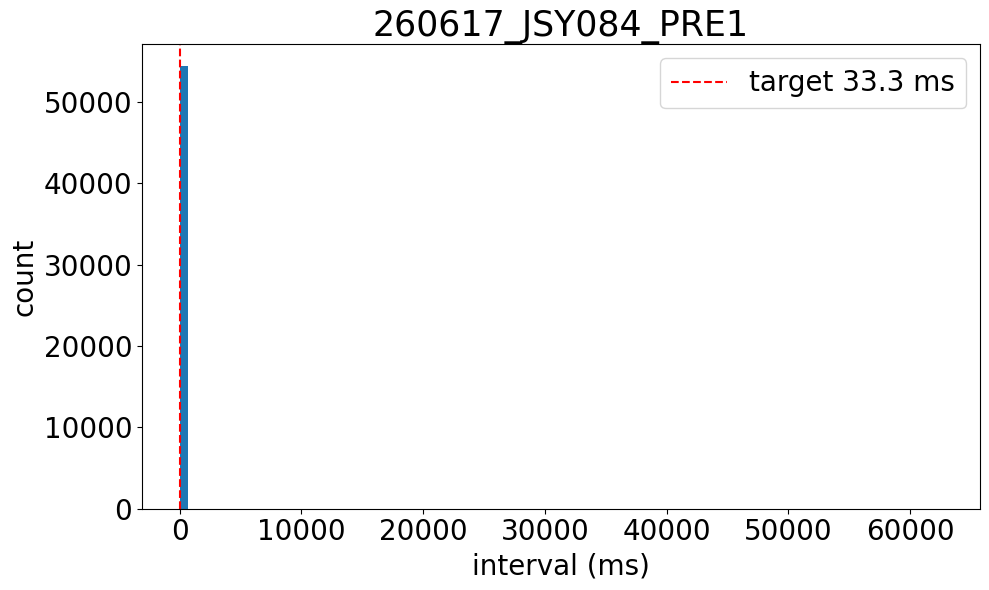

  median=33.33 ms  p99=33.33 ms  max=62599.94 ms
  260617_JSY084_PRE1: 54252 frames -> 6 file(s) in H:\jasmine\lick_videos\260617_JSY084_PRE1_splited
  ffprobe frames=54361  written=54252  MISMATCH

=== 260618_JSY083_B1 ===
  saved 54719 timestamps -> 260618_JSY083_B1_timestamps.csv


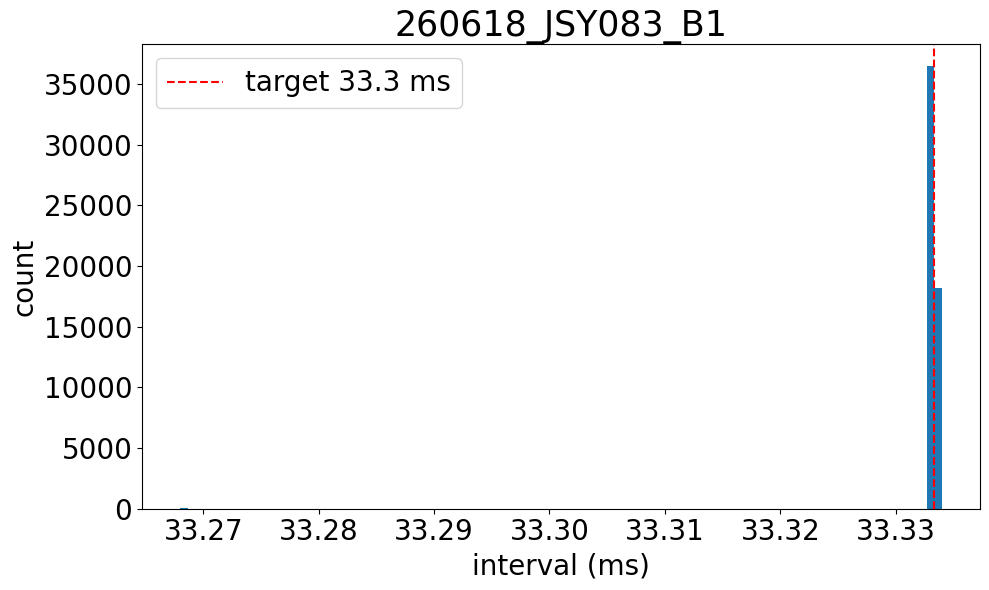

  median=33.33 ms  p99=33.33 ms  max=33.33 ms
  260618_JSY083_B1: 54719 frames -> 6 file(s) in H:\jasmine\lick_videos\260618_JSY083_B1_splited
  ffprobe frames=54719  written=54719  OK

=== 260618_JSY084_B1 ===
  saved 55268 timestamps -> 260618_JSY084_B1_timestamps.csv


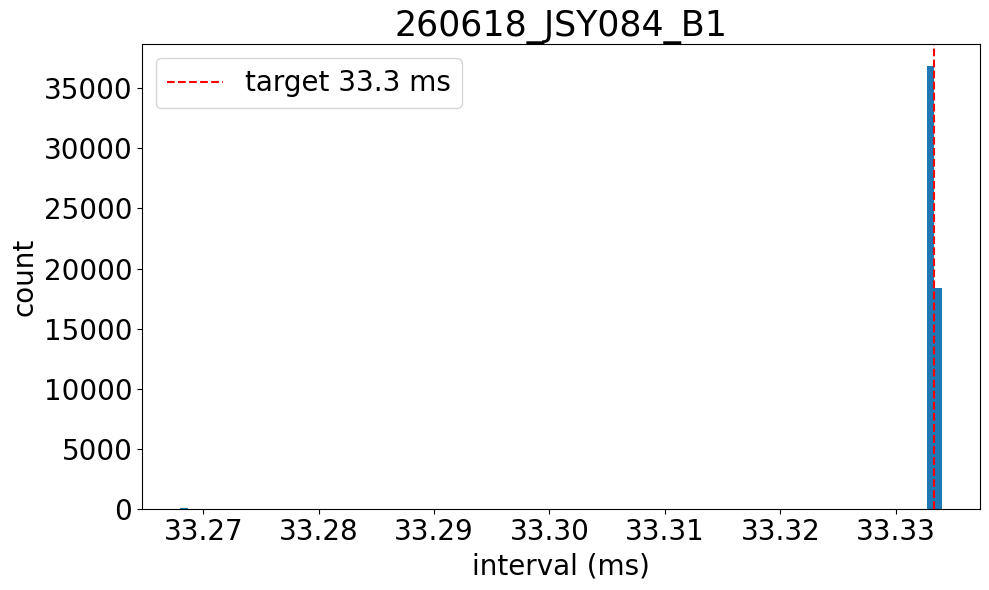

  median=33.33 ms  p99=33.33 ms  max=33.33 ms
  260618_JSY084_B1: 55268 frames -> 6 file(s) in H:\jasmine\lick_videos\260618_JSY084_B1_splited
  ffprobe frames=55268  written=55268  OK

=== 260619_JSY083_B2 ===
  saved 64981 timestamps -> 260619_JSY083_B2_timestamps.csv


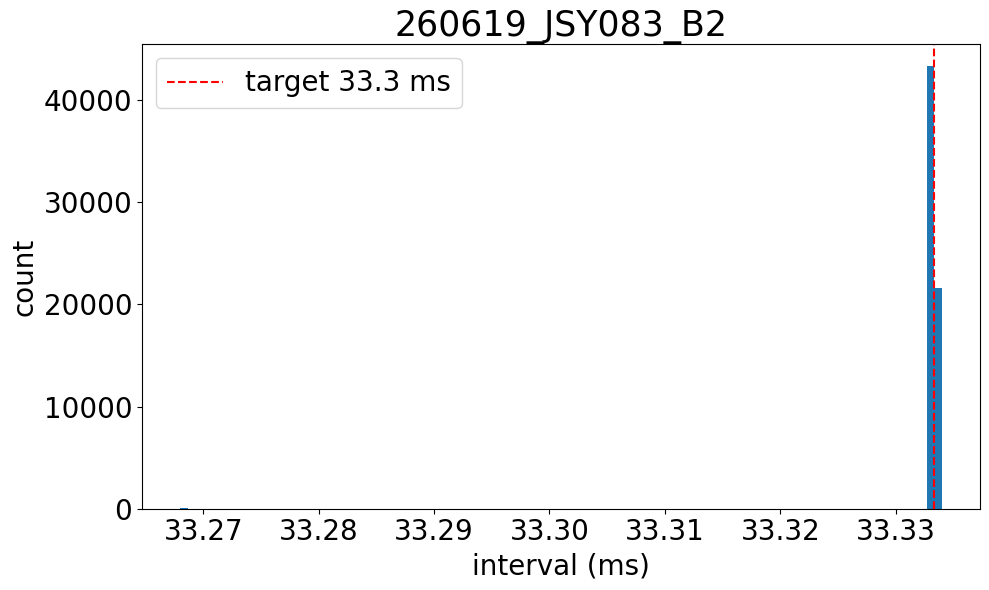

  median=33.33 ms  p99=33.33 ms  max=33.33 ms
  260619_JSY083_B2: 64981 frames -> 7 file(s) in H:\jasmine\lick_videos\260619_JSY083_B2_splited
  ffprobe frames=64981  written=64981  OK

=== 260619_JSY084_B2 ===
  saved 64890 timestamps -> 260619_JSY084_B2_timestamps.csv


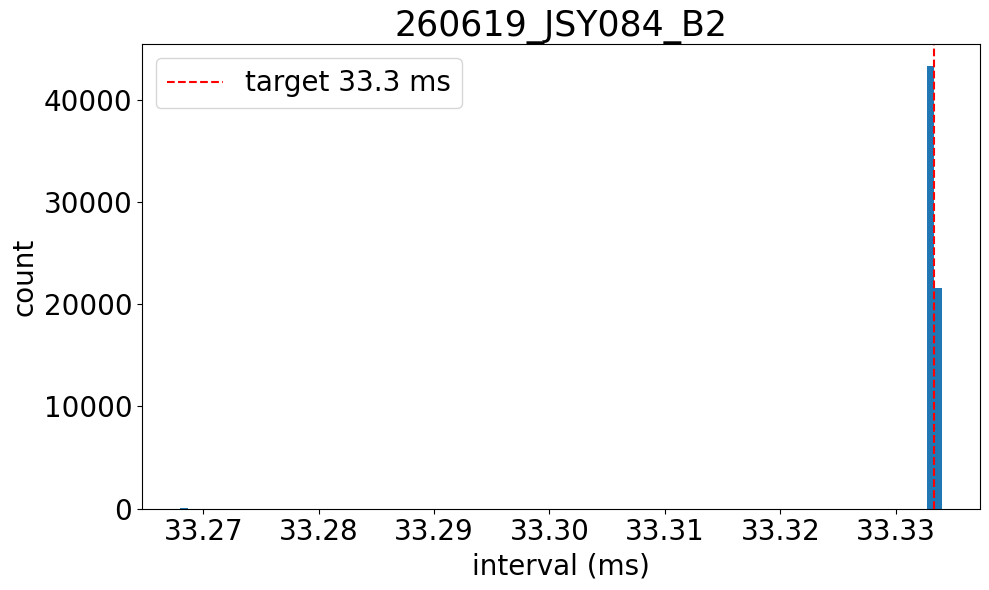

  median=33.33 ms  p99=33.33 ms  max=33.33 ms
  260619_JSY084_B2: 64890 frames -> 7 file(s) in H:\jasmine\lick_videos\260619_JSY084_B2_splited
  ffprobe frames=64890  written=64890  OK

=== 260620_JSY083_B3 ===
  saved 63916 timestamps -> 260620_JSY083_B3_timestamps.csv


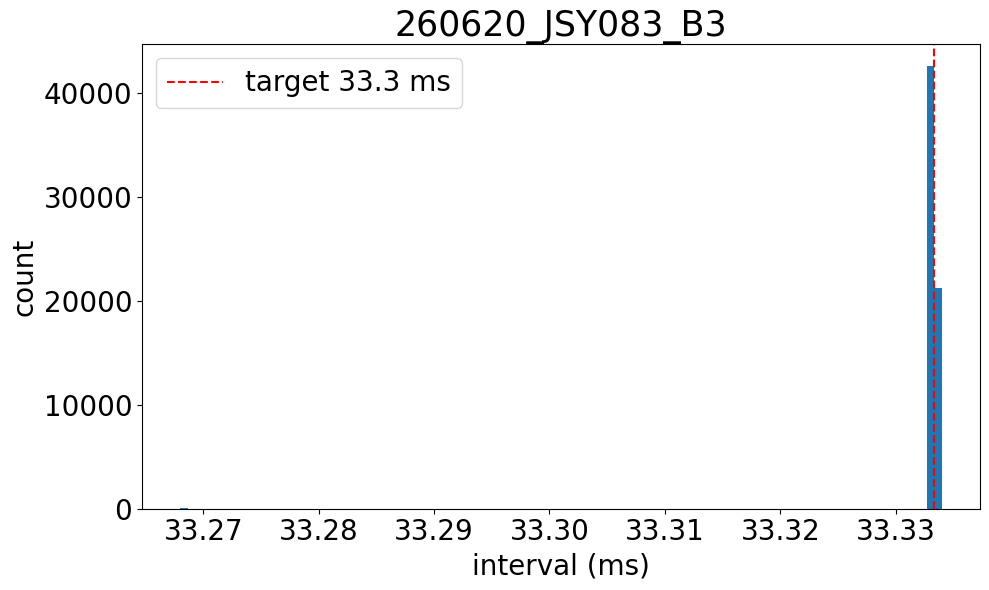

  median=33.33 ms  p99=33.33 ms  max=33.33 ms
  260620_JSY083_B3: 63916 frames -> 7 file(s) in H:\jasmine\lick_videos\260620_JSY083_B3_splited
  ffprobe frames=63916  written=63916  OK

=== 260620_JSY084_B3 ===
  saved 63688 timestamps -> 260620_JSY084_B3_timestamps.csv


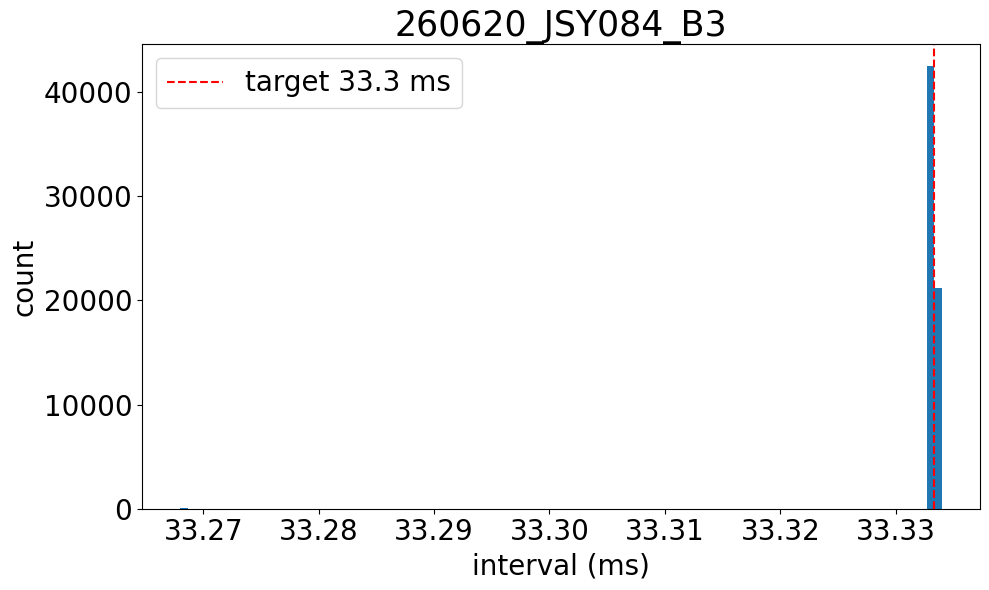

  median=33.33 ms  p99=33.33 ms  max=33.33 ms
  260620_JSY084_B3: 63688 frames -> 7 file(s) in H:\jasmine\lick_videos\260620_JSY084_B3_splited
  ffprobe frames=63688  written=63688  OK

=== 260621_JSY083_B4 ===
  saved 73421 timestamps -> 260621_JSY083_B4_timestamps.csv


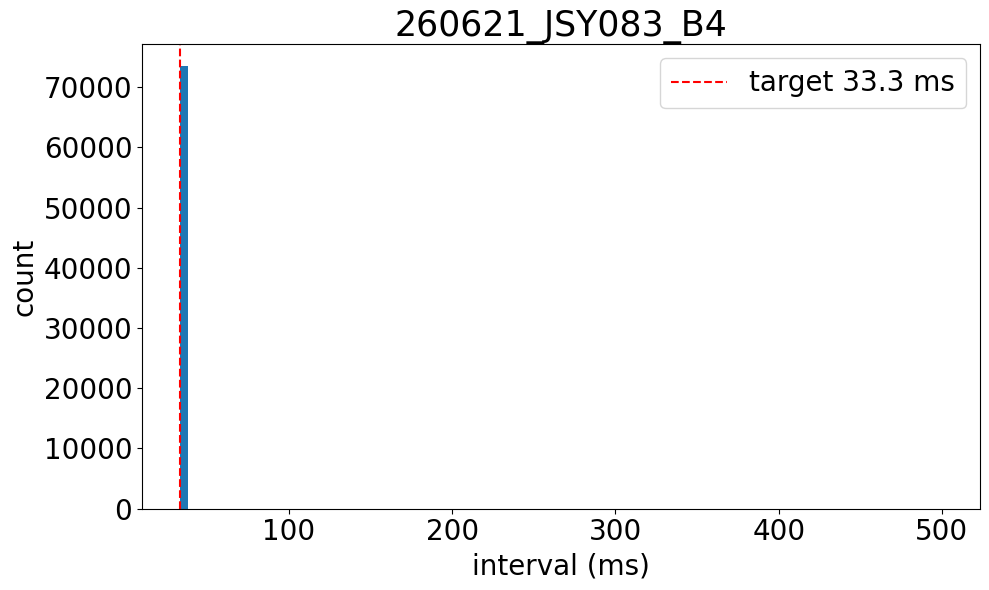

  median=33.33 ms  p99=33.33 ms  max=500.00 ms
  260621_JSY083_B4: 73421 frames -> 8 file(s) in H:\jasmine\lick_videos\260621_JSY083_B4_splited
  ffprobe frames=73421  written=73421  OK

=== 260621_JSY084_B4 ===
  saved 71895 timestamps -> 260621_JSY084_B4_timestamps.csv


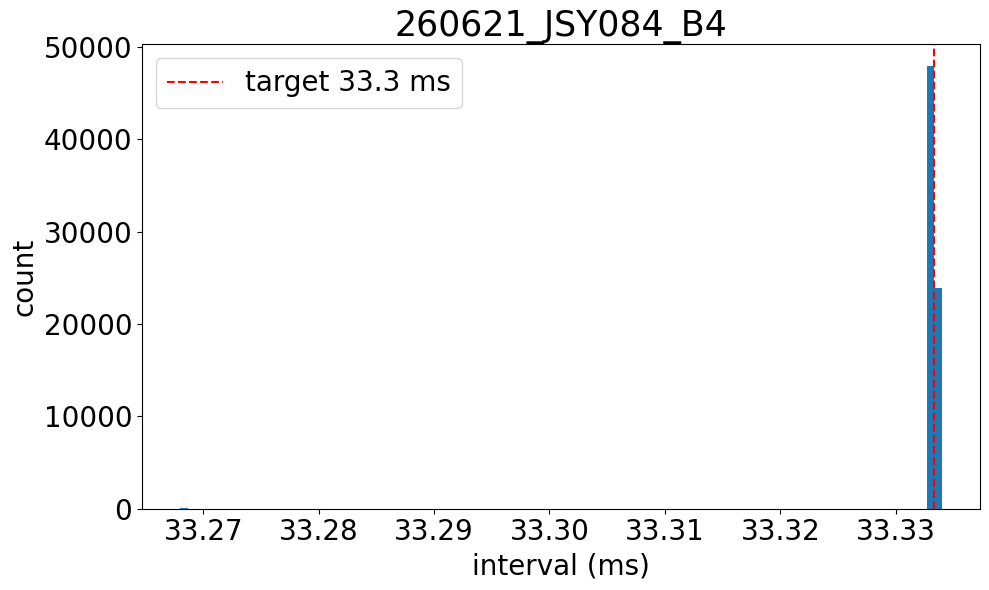

  median=33.33 ms  p99=33.33 ms  max=33.33 ms
  260621_JSY084_B4: 71895 frames -> 8 file(s) in H:\jasmine\lick_videos\260621_JSY084_B4_splited
  ffprobe frames=71895  written=71895  OK

=== 260622_JSY083_B5 ===
  saved 55703 timestamps -> 260622_JSY083_B5_timestamps.csv


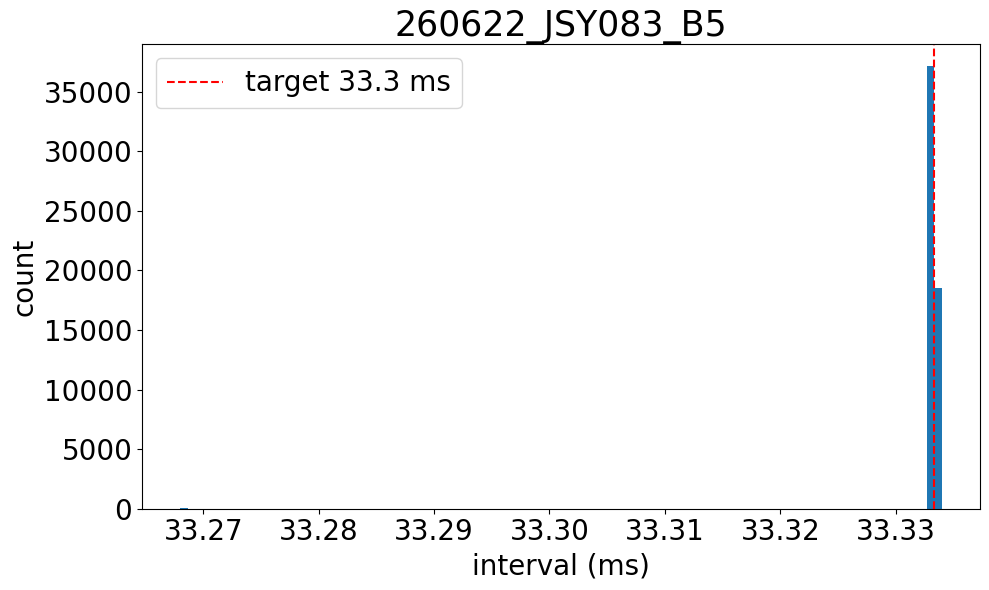

  median=33.33 ms  p99=33.33 ms  max=33.33 ms
  260622_JSY083_B5: 55703 frames -> 6 file(s) in H:\jasmine\lick_videos\260622_JSY083_B5_splited
  ffprobe frames=55703  written=55703  OK

=== 260622_JSY084_B5 ===
  saved 63360 timestamps -> 260622_JSY084_B5_timestamps.csv


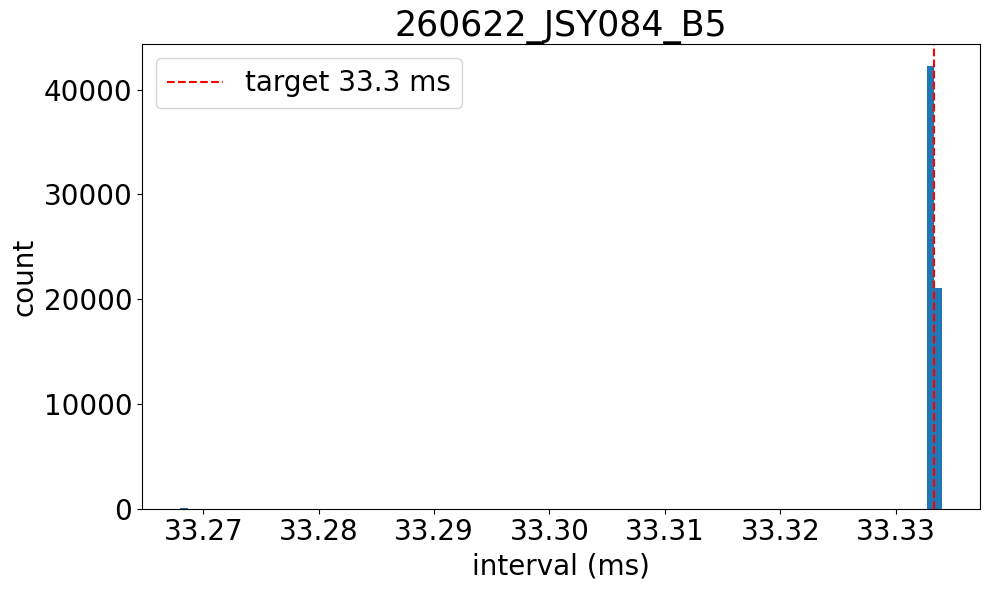

  median=33.33 ms  p99=33.33 ms  max=33.33 ms
  260622_JSY084_B5: 63360 frames -> 7 file(s) in H:\jasmine\lick_videos\260622_JSY084_B5_splited
  ffprobe frames=63360  written=63360  OK

=== 260623_JSY083_B6 ===
  saved 71585 timestamps -> 260623_JSY083_B6_timestamps.csv


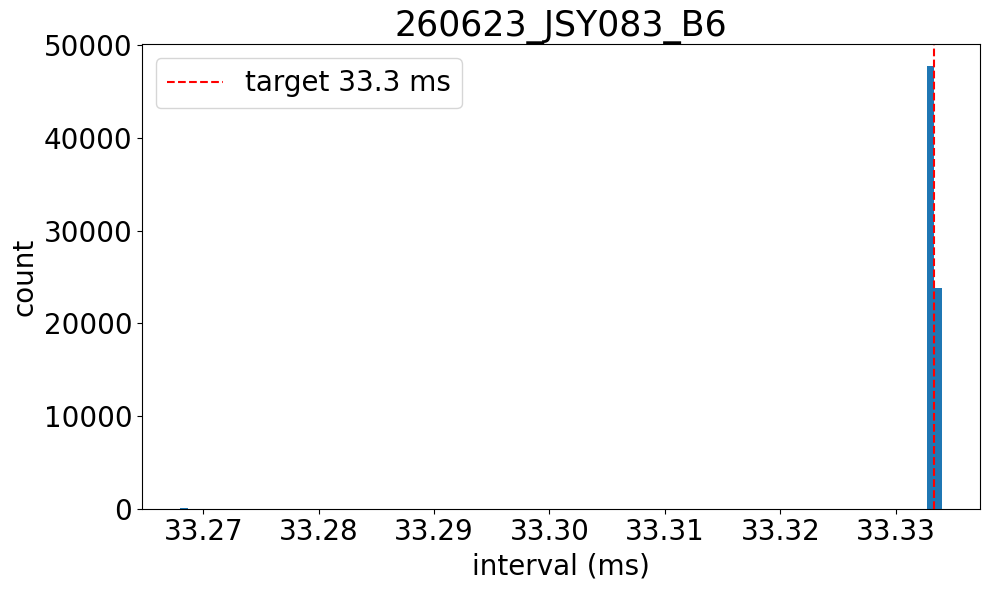

  median=33.33 ms  p99=33.33 ms  max=33.33 ms
  260623_JSY083_B6: 71585 frames -> 8 file(s) in H:\jasmine\lick_videos\260623_JSY083_B6_splited
  ffprobe frames=71585  written=71585  OK

=== 260623_JSY084_B6 ===
  saved 71995 timestamps -> 260623_JSY084_B6_timestamps.csv


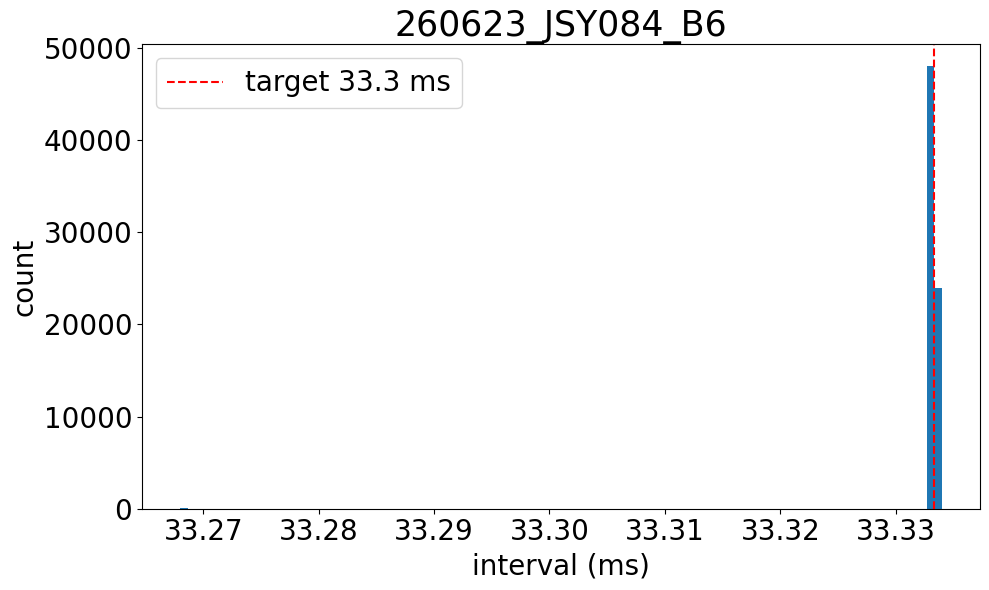

  median=33.33 ms  p99=33.33 ms  max=33.33 ms
  260623_JSY084_B6: 71995 frames -> 8 file(s) in H:\jasmine\lick_videos\260623_JSY084_B6_splited
  ffprobe frames=71995  written=71995  OK

=== 260624_JSY083_B7 ===
  saved 73128 timestamps -> 260624_JSY083_B7_timestamps.csv


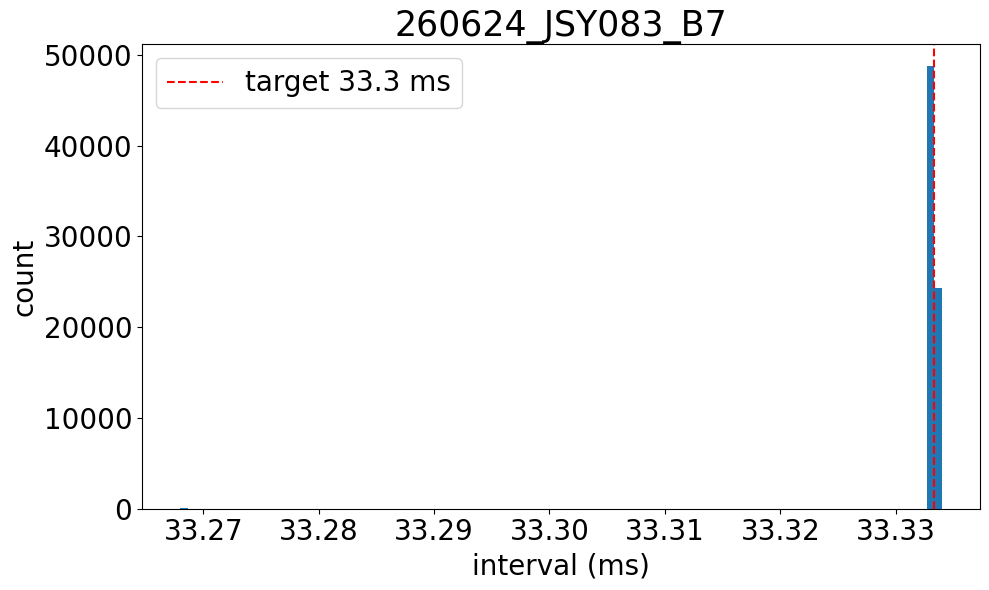

  median=33.33 ms  p99=33.33 ms  max=33.33 ms
  260624_JSY083_B7: 73128 frames -> 8 file(s) in H:\jasmine\lick_videos\260624_JSY083_B7_splited
  ffprobe frames=73128  written=73128  OK

=== 260624_JSY084_B7 ===
  saved 76582 timestamps -> 260624_JSY084_B7_timestamps.csv


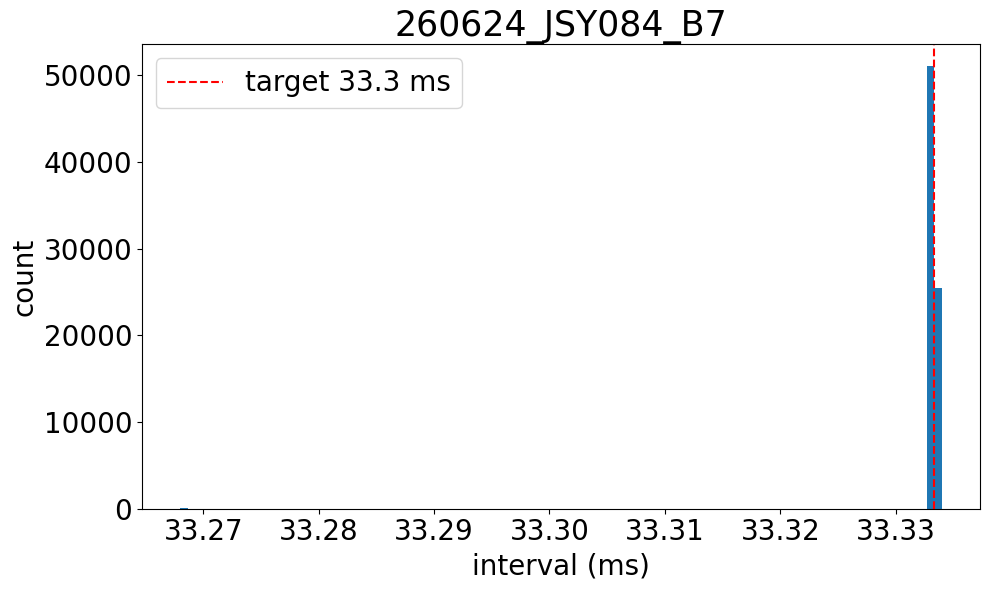

  median=33.33 ms  p99=33.33 ms  max=33.33 ms
  260624_JSY084_B7: 76582 frames -> 8 file(s) in H:\jasmine\lick_videos\260624_JSY084_B7_splited
  ffprobe frames=76582  written=76582  OK

=== 260625_JSY083_B8 ===
  saved 81355 timestamps -> 260625_JSY083_B8_timestamps.csv


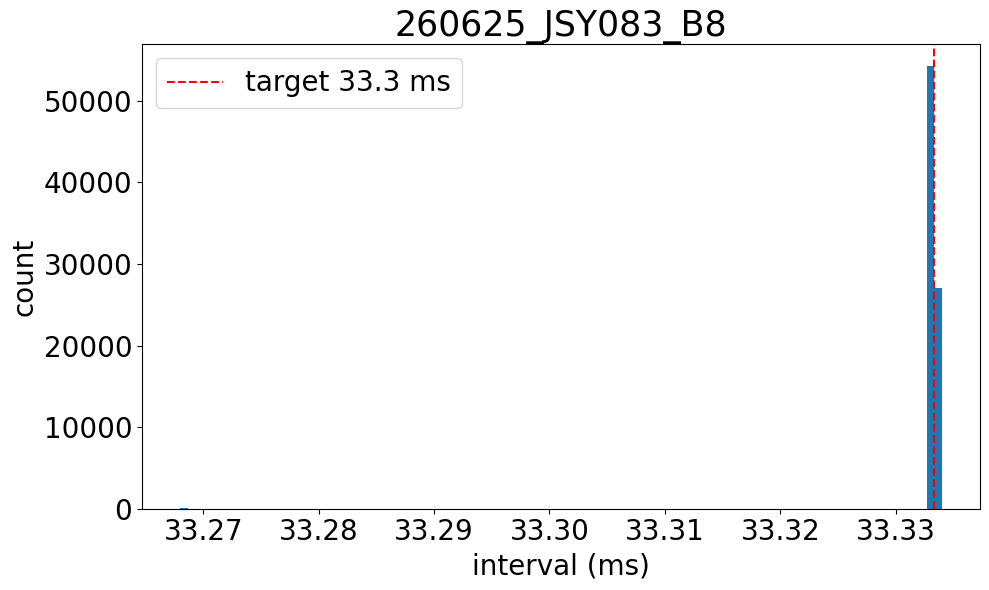

  median=33.33 ms  p99=33.33 ms  max=33.33 ms
  260625_JSY083_B8: 81355 frames -> 9 file(s) in H:\jasmine\lick_videos\260625_JSY083_B8_splited
  ffprobe frames=81355  written=81355  OK

=== 260625_JSY084_B8 ===
  saved 70897 timestamps -> 260625_JSY084_B8_timestamps.csv


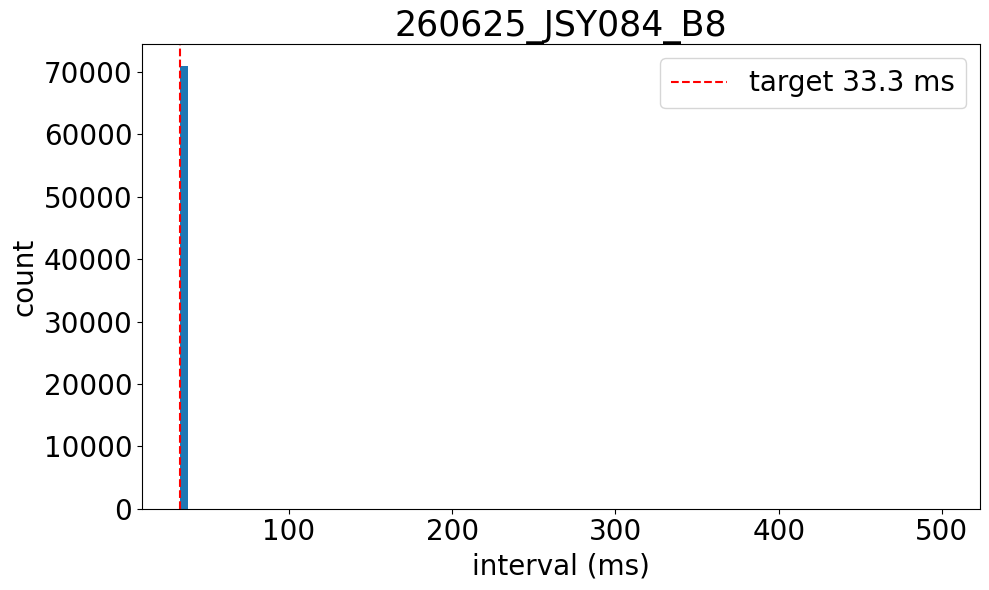

  median=33.33 ms  p99=33.33 ms  max=500.00 ms
  260625_JSY084_B8: 70897 frames -> 8 file(s) in H:\jasmine\lick_videos\260625_JSY084_B8_splited
  ffprobe frames=70897  written=70897  OK

=== 260626_JSY083_Saline ===
  saved 83791 timestamps -> 260626_JSY083_Saline_timestamps.csv


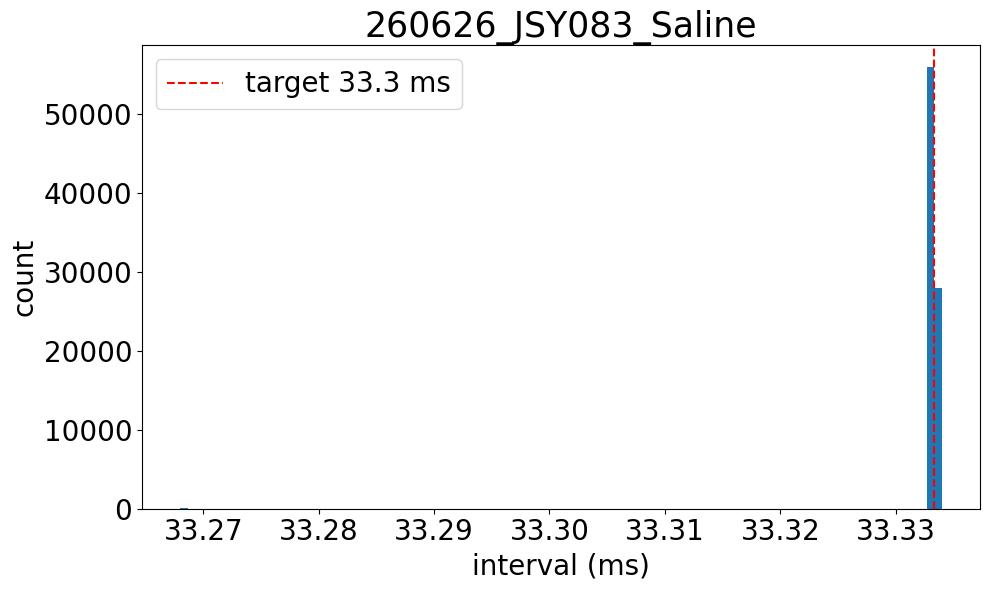

  median=33.33 ms  p99=33.33 ms  max=33.33 ms
  260626_JSY083_Saline: 83791 frames -> 9 file(s) in H:\jasmine\lick_videos\260626_JSY083_Saline_splited
  ffprobe frames=83791  written=83791  OK

=== 260626_JSY084_Saline ===
  saved 81580 timestamps -> 260626_JSY084_Saline_timestamps.csv


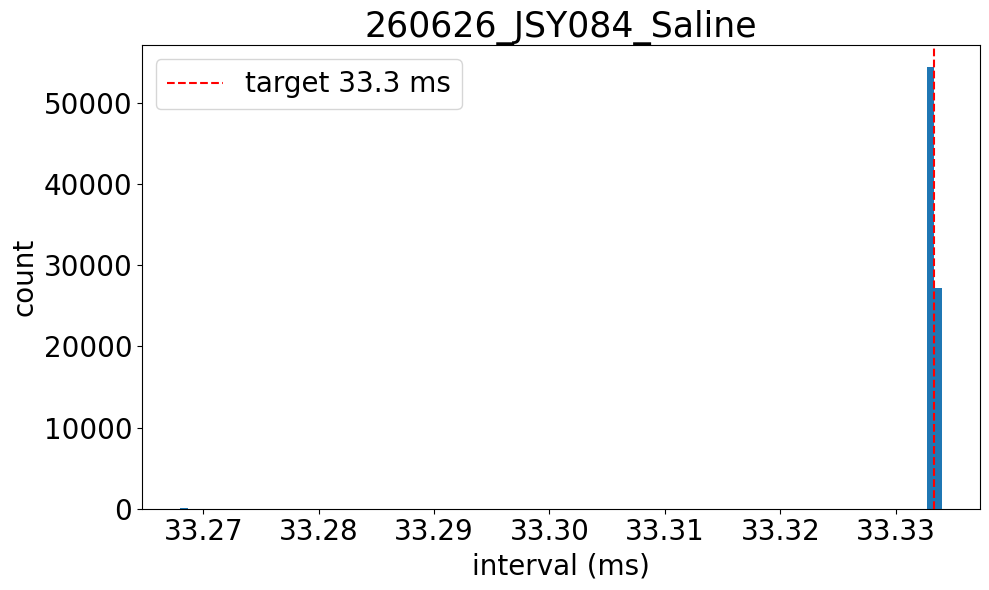

  median=33.33 ms  p99=33.33 ms  max=33.33 ms
  260626_JSY084_Saline: 81580 frames -> 9 file(s) in H:\jasmine\lick_videos\260626_JSY084_Saline_splited
  ffprobe frames=81580  written=81580  OK

=== 260628_JSY083_DCZ100 ===
  saved 81628 timestamps -> 260628_JSY083_DCZ100_timestamps.csv


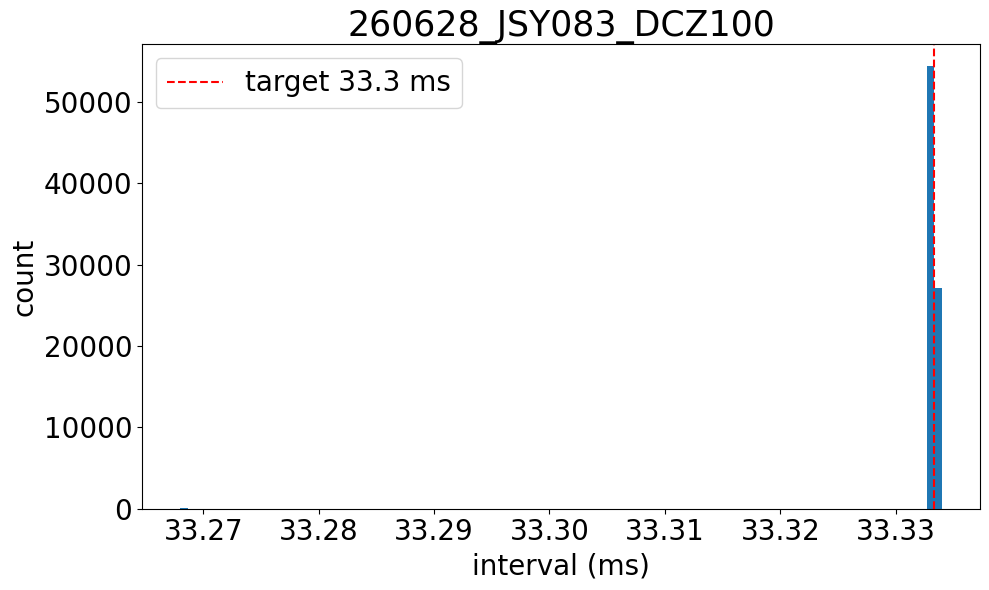

  median=33.33 ms  p99=33.33 ms  max=33.33 ms
  260628_JSY083_DCZ100: 81628 frames -> 9 file(s) in H:\jasmine\lick_videos\260628_JSY083_DCZ100_splited
  ffprobe frames=81628  written=81628  OK

=== 260628_JSY084_DCZ100 ===
  saved 82017 timestamps -> 260628_JSY084_DCZ100_timestamps.csv


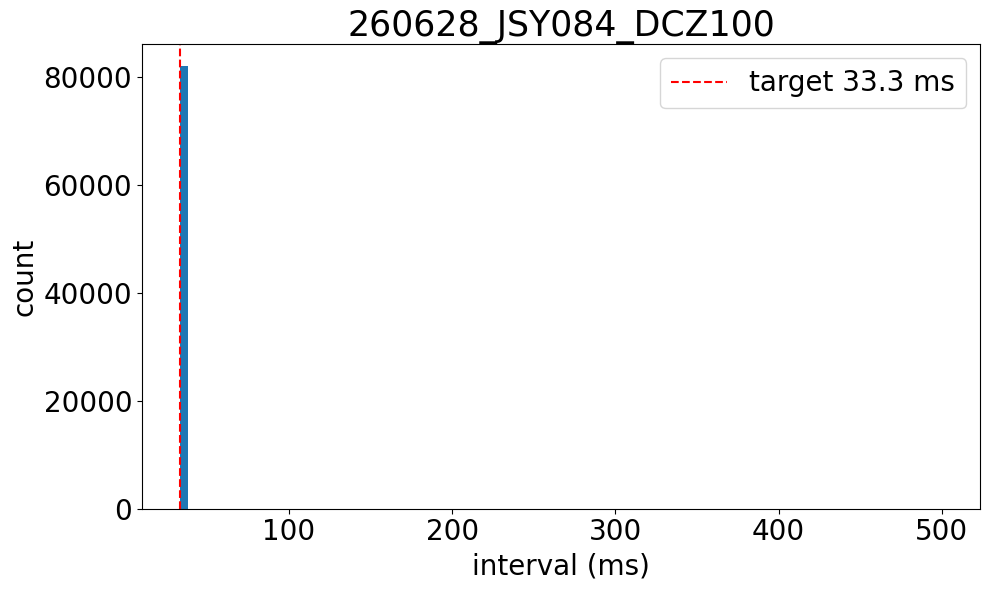

  median=33.33 ms  p99=33.33 ms  max=500.00 ms
  260628_JSY084_DCZ100: 82017 frames -> 9 file(s) in H:\jasmine\lick_videos\260628_JSY084_DCZ100_splited
  ffprobe frames=82017  written=82017  OK

=== 260630_JSY083_DCZ200 ===
  saved 80341 timestamps -> 260630_JSY083_DCZ200_timestamps.csv


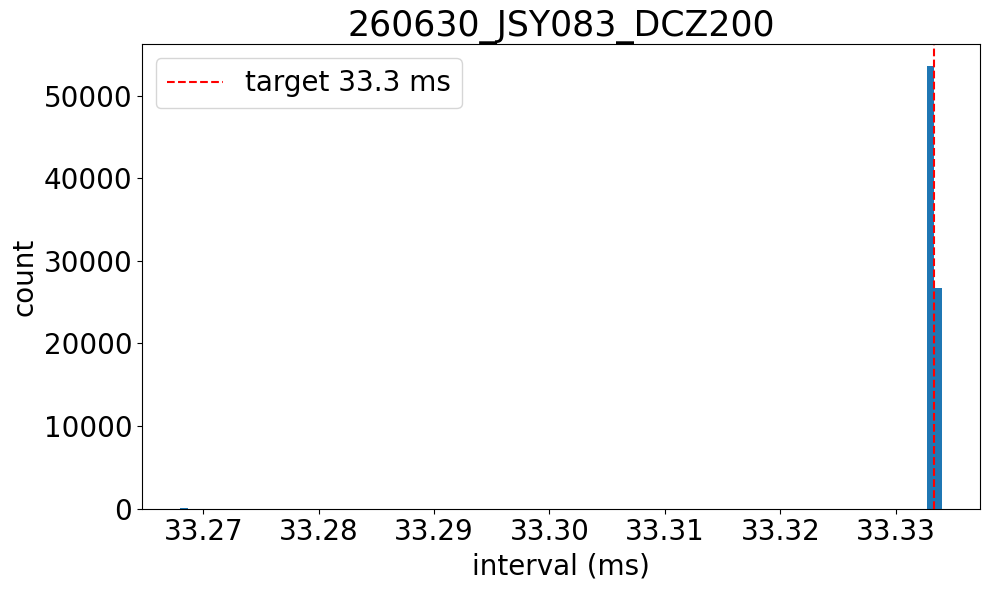

  median=33.33 ms  p99=33.33 ms  max=33.33 ms
  260630_JSY083_DCZ200: 80341 frames -> 9 file(s) in H:\jasmine\lick_videos\260630_JSY083_DCZ200_splited
  ffprobe frames=80341  written=80341  OK

=== 260630_JSY084_DCZ200 ===
  saved 81166 timestamps -> 260630_JSY084_DCZ200_timestamps.csv


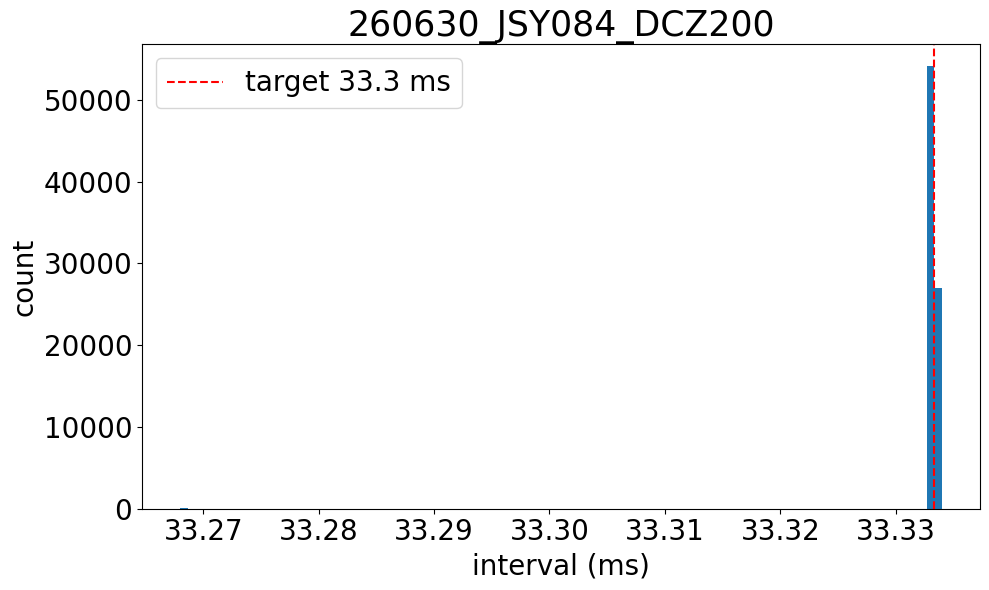

  median=33.33 ms  p99=33.33 ms  max=33.33 ms
  260630_JSY084_DCZ200: 81166 frames -> 9 file(s) in H:\jasmine\lick_videos\260630_JSY084_DCZ200_splited
  ffprobe frames=81166  written=81166  OK


,total_read,n_splits,out_dir,base,ffprobe_frames,match
0,54933,6,H:\jasmine\lick_videos\260617_JSY083_PRE1_splited,260617_JSY083_PRE1,54933,True
1,54252,6,H:\jasmine\lick_videos\260617_JSY084_PRE1_splited,260617_JSY084_PRE1,54361,False
2,54719,6,H:\jasmine\lick_videos\260618_JSY083_B1_splited,260618_JSY083_B1,54719,True
3,55268,6,H:\jasmine\lick_videos\260618_JSY084_B1_splited,260618_JSY084_B1,55268,True
4,64981,7,H:\jasmine\lick_videos\260619_JSY083_B2_splited,260619_JSY083_B2,64981,True
5,64890,7,H:\jasmine\lick_videos\260619_JSY084_B2_splited,260619_JSY084_B2,64890,True
6,63916,7,H:\jasmine\lick_videos\260620_JSY083_B3_splited,260620_JSY083_B3,63916,True
7,63688,7,H:\jasmine\lick_videos\260620_JSY084_B3_splited,260620_JSY084_B3,63688,True
8,73421,8,H:\jasmine\lick_videos\260621_JSY083_B4_splited,260621_JSY083_B4,73421,True
9,71895,8,H:\jasmine\lick_videos\260621_JSY084_B4_splited,260621_JSY084_B4,71895,True


In [16]:
def run_all(root_dir=ROOT_DIR, chunk_size=CHUNK_SIZE, codec=CODEC,
            do_diagnostic=True):
    videos = discover_videos(root_dir)
    summary = []
    for v in videos:
        print(f"\n=== {v['base']} ===")
        ts = extract_timestamps(v["path"])
        if do_diagnostic:
            plot_intervals(ts, title=v["base"])

        res = split_one(v["path"], v["base"], root_dir,
                        chunk_size=chunk_size, codec=codec)

        # frame-conservation check: ffprobe count vs frames written
        match = (len(ts) == res["total_read"])
        print(f"  ffprobe frames={len(ts)}  written={res['total_read']}  "
              f"{'OK' if match else 'MISMATCH'}")
        summary.append({**res, "base": v["base"],
                        "ffprobe_frames": len(ts), "match": match})
    return pd.DataFrame(summary)

results = run_all()
results